# SEABED OBJECT CLASSIFICATION MODEL DEVELOPMENT

## MISSION OVERVIEW
This notebook deploys a Vision Transformer (ViT) model for seabed object classification operations. Based on Google's VIT-Base-Patch16-224 architecture from the [HuggingFace model hub](https://huggingface.co/google/vit-base-patch16-224) with implementation guidance from [HuggingFace classification examples](https://huggingface.co/docs/transformers/en/tasks/image_classification).

## SYSTEM SETUP INSTRUCTIONS

**OPERATIONAL NOTICE:** Execute the cell below to install required dependencies. If system indicates kernel restart required:

1. **Restart the kernel** (Kernel → Restart)
2. **Re-run the dependency cell** to verify installation
3. **Continue with operational procedures**

This ensures compatibility between NumPy, TensorFlow, and other ML libraries.

In [1]:
# Fix compatibility issues and install required dependencies
import subprocess
import sys
import warnings
import os

# Suppress warnings and pip output for cleaner display
warnings.filterwarnings('ignore')
os.environ['PIP_QUIET'] = '1'

def install_package(package, quiet=True):
    """Install package with pip, suppressing output unless there's error"""
    try:
        if quiet:
            # Redirect stdout and stderr to suppress "requirement already satisfied" messages
            result = subprocess.run(
                [sys.executable, "-m", "pip", "install", "--user", package],
                capture_output=True,
                text=True,
                check=True
            )
            return True, ""
        else:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", package])
            return True, ""
    except subprocess.CalledProcessError as e:
        return False, str(e)

print("🔧 Checking and installing dependencies...")

# Install required packages for compatibility
try:
    import numpy
    if numpy.__version__.startswith('2.'):
        print("   📦 Downgrading NumPy for compatibility...")
        success, error = install_package("numpy<2")
        if success:
            print("   ✅ NumPy downgraded successfully")
            print("   🔄 Please restart kernel and re-run this cell")
        else:
            print(f"   ❌ Error downgrading NumPy: {error}")
    else:
        print(f"   ✅ NumPy {numpy.__version__} is compatible")
except ImportError:
    print("   📦 Installing NumPy...")
    success, error = install_package("numpy<2")
    if success:
        print("   ✅ NumPy installed successfully")
    else:
        print(f"   ❌ Error installing NumPy: {error}")

try:
    import tf_keras
    print("   ✅ tf-keras is available")
except ImportError:
    print("   📦 Installing tf-keras for Transformers compatibility...")
    success, error = install_package("tf-keras")
    if success:
        print("   ✅ tf-keras installed successfully")
        print("   🔄 Please restart kernel and re-run this cell")
    else:
        print(f"   ❌ Error installing tf-keras: {error}")

# Enhanced accelerate package installation and verification
accelerate_installed = False
accelerate_version_ok = False

try:
    import accelerate
    from packaging import version
    
    # Check if accelerate version is sufficient
    min_version = "0.26.0"
    current_version = accelerate.__version__
    
    if version.parse(current_version) >= version.parse(min_version):
        print(f"   ✅ accelerate {current_version} is available and compatible")
        accelerate_installed = True
        accelerate_version_ok = True
    else:
        print(f"   ⚠️  accelerate {current_version} is too old (need >={min_version})")
        accelerate_installed = True
        accelerate_version_ok = False
        
except ImportError:
    print("   📦 accelerate not found")
    accelerate_installed = False

# Install or upgrade accelerate if needed
if not accelerate_installed or not accelerate_version_ok:
    print("   📦 Installing/upgrading accelerate for Transformers Trainer...")
    success, error = install_package("accelerate>=0.26.0 --upgrade")
    if success:
        print("   ✅ accelerate installed/upgraded successfully")
        print("   🔄 Please restart kernel and re-run this cell")
        
        # Try to import again to verify
        try:
            import accelerate
            print(f"   ✅ Verified: accelerate {accelerate.__version__} is now available")
        except ImportError:
            print("   ⚠️  accelerate installation may require kernel restart")
    else:
        print(f"   ❌ Error installing accelerate: {error}")

# Check MLflow and Optuna for hyperparameter optimization
try:
    import mlflow
    import optuna
    print(f"   ✅ mlflow {mlflow.__version__} is available")
    print(f"   ✅ optuna {optuna.__version__} is available")
except ImportError:
    print("   📦 Installing optimization libraries...")
    success1, error1 = install_package("mlflow")
    success2, error2 = install_package("optuna")
    if success1 and success2:
        print("   ✅ mlflow and optuna installed successfully")
    else:
        if error1: print(f"   ❌ Error installing mlflow: {error1}")
        if error2: print(f"   ❌ Error installing optuna: {error2}")

# Check transformers compatibility with TrainingArguments
try:
    from transformers import TrainingArguments
    # Test creating TrainingArguments with corrected parameter
    test_args = TrainingArguments(
        output_dir="/tmp/test",
        eval_strategy="epoch",  # Fixed parameter name
        num_train_epochs=1
    )
    print("   ✅ Transformers TrainingArguments compatibility verified")
    
    # Clean up test args
    del test_args
    
except Exception as e:
    print(f"   ⚠️  Transformers compatibility issue: {str(e)}")
    
    # Check if it's specifically an accelerate import error
    if "accelerate" in str(e).lower():
        print("   📦 Accelerate dependency issue detected - installing transformers[torch]...")
        success, error = install_package("transformers[torch] --upgrade")
        if success:
            print("   ✅ transformers[torch] installed")
            print("   🔄 Please restart kernel and re-run this cell")
        else:
            print(f"   ❌ Error installing transformers[torch]: {error}")
    else:
        print("   📦 Updating transformers...")
        success, error = install_package("transformers>=4.20.0 --upgrade")
        if success:
            print("   ✅ transformers updated")
            print("   🔄 Please restart kernel and re-run this cell")
        else:
            print(f"   ❌ Error updating transformers: {error}")

print("\n🎯 All dependencies are ready!")
print("   → If you see restart messages above, restart kernel and re-run this cell")
print("   → You can now proceed with hyperparameter optimization")

🔧 Checking and installing dependencies...


2025-10-14 22:19:11.464844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered


   ✅ NumPy 1.26.4 is compatible


E0000 00:00:1760480351.490229   10575 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760480351.497459   10575 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760480351.515992   10575 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760480351.516014   10575 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760480351.516016   10575 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760480351.516019   10575 computation_placer.cc:177] computation placer already registered. Please check linka

   ✅ tf-keras is available
   ✅ accelerate 1.10.1 is available and compatible
   ✅ mlflow 2.21.3 is available
   ✅ optuna 4.5.0 is available
   ✅ Transformers TrainingArguments compatibility verified

🎯 All dependencies are ready!
   → If you see restart messages above, restart kernel and re-run this cell
   → You can now proceed with hyperparameter optimization


In [2]:
# Suppress warnings for cleaner output
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow info/warning messages

# Import all required packages with enhanced error checking
try:
    from transformers import (
        AutoImageProcessor,
        AutoModelForImageClassification,
        pipeline,
        TrainingArguments,
        Trainer,
        DefaultDataCollator
    )
    from transformers.integrations import MLflowCallback
    print("✅ Transformers imports successful")
except ImportError as e:
    print(f"❌ Transformers import error: {e}")
    print("   → Please run the dependency installation cell and restart kernel")

try:
    from PIL import Image
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    print("✅ Basic data science packages imported")
except ImportError as e:
    print(f"❌ Basic package import error: {e}")

try:
    import torch
    from torchvision.transforms import Compose, RandomResizedCrop, ToTensor, Normalize
    from torch.utils.data import Dataset, DataLoader
    print("✅ PyTorch packages imported")
    print(f"   PyTorch version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
except ImportError as e:
    print(f"❌ PyTorch import error: {e}")

try:
    import evaluate
    print("✅ Evaluate library imported")
except ImportError as e:
    print(f"❌ Evaluate import error: {e}")

try:
    import mlflow
    import optuna
    import mlflow.pytorch
    import tempfile
    import shutil
    from mlflow.tracking import MlflowClient
    print("✅ MLflow and Optuna optimization libraries imported")
    print(f"   MLflow version: {mlflow.__version__}")
    print(f"   Optuna version: {optuna.__version__}")
except ImportError as e:
    print(f"❌ Optimization libraries import error: {e}")

# Test accelerate specifically since it was the problem
try:
    import accelerate
    print(f"✅ accelerate {accelerate.__version__} imported successfully")
except ImportError as e:
    print(f"❌ accelerate import error: {e}")
    print("   → This is likely the cause of TrainingArguments issues")

# Test TrainingArguments specifically
try:
    test_args = TrainingArguments(
        output_dir="/tmp/test_args_verification",
        eval_strategy="epoch",
        num_train_epochs=1
    )
    print("✅ TrainingArguments test successful")
    del test_args  # Clean up
except Exception as e:
    print(f"❌ TrainingArguments test failed: {e}")
    print("   → This indicates dependency issues - please restart kernel after installing dependencies")

print(f"\n📊 System Info:")
print(f"   NumPy version: {np.__version__}")
if 'torch' in locals():
    print(f"   PyTorch version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
else:
    print("   PyTorch: Not available")
if 'mlflow' in locals():
    print(f"   MLflow version: {mlflow.__version__}")
if 'optuna' in locals():
    print(f"   Optuna version: {optuna.__version__}")

✅ Transformers imports successful
✅ Basic data science packages imported
✅ PyTorch packages imported
   PyTorch version: 2.8.0+cu128
   CUDA available: True
✅ Evaluate library imported
✅ MLflow and Optuna optimization libraries imported
   MLflow version: 2.21.3
   Optuna version: 4.5.0
✅ accelerate 1.10.1 imported successfully
✅ TrainingArguments test successful

📊 System Info:
   NumPy version: 1.26.4
   PyTorch version: 2.8.0+cu128
   CUDA available: True
   MLflow version: 2.21.3
   Optuna version: 4.5.0


In [3]:
# Data Configuration - Import centralized configuration
import sys
from pathlib import Path
import os

# Add src directory to path for imports
working_dir = os.environ.get('DOMINO_WORKING_DIR', '/mnt')
sys.path.insert(0, working_dir)

# Import the centralized DataConfig
from src.data_config import DataConfig

# Initialize data configuration
config = DataConfig()
config.print_config()

📁 DATA CONFIGURATION
📂 Project: Seabed-Object-Classifier
🏠 Working Dir: /mnt/code
📊 Base Data Path: /mnt/data/Seabed-Object-Classifier
🚂 Training Data: /mnt/data/Seabed-Object-Classifier/unbalanced_training_validation_set
🧪 Test Data: /mnt/data/Seabed-Object-Classifier/test_set
💾 Model Output: /mnt/artifacts/models/vit_classification_model
🏷️  Classes: ['plane', 'ship', 'seafloor']

✅ All paths validated successfully!


### DATA PROCESSING

In [4]:
# Check if a GPU is available
device = 0 if torch.cuda.is_available() else -1  # 0 for the first GPU, -1 for CPU

if device == 0:
    print("Running on GPU")
else:
    print("No GPU detected. Running on CPU")

Running on GPU


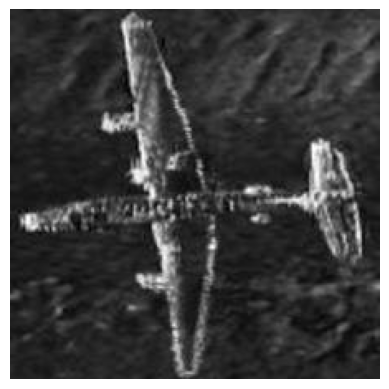

✅ Displaying: 12.jpg


In [5]:
# Function to display image using config paths
def display_image(image_path):
    """Display an image with error handling"""
    try:
        if os.path.exists(image_path):
            img = Image.open(image_path).convert("RGB")
            plt.imshow(img)
            plt.axis('off')
            plt.show()
            print(f"✅ Displaying: {os.path.basename(image_path)}")
        else:
            print(f"❌ Image not found: {image_path}")
    except Exception as e:
        print(f"❌ Error loading image: {e}")

# Example: Display an image from the training set using config
sample_image_path = os.path.join(config.train_images, 'plane', '12.jpg')

# Check if the specific image exists, if not find any plane image
if not os.path.exists(sample_image_path):
    plane_dir = os.path.join(config.train_images, 'plane')
    if os.path.exists(plane_dir):
        plane_images = [f for f in os.listdir(plane_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        if plane_images:
            sample_image_path = os.path.join(plane_dir, plane_images[0])
            print(f"📸 Using alternative image: {plane_images[0]}")
        else:
            print("⚠️  No plane images found!")
    else:
        print(f"⚠️  Plane directory not found: {plane_dir}")

display_image(sample_image_path)

In [6]:
# Create DataFrame of images with comprehensive statistics using config
def create_image_dataframe(data_dir, classes):
    """Create DataFrame with improved error handling and validation"""
    image_names, classifications = [], []
    class_counts = {}
    
    print(f"📊 Scanning directory: {data_dir}")
    
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        if os.path.isdir(class_dir):
            class_files = [file_name for file_name in os.listdir(class_dir) 
                          if file_name.endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(class_files)
            image_names.extend(class_files)
            classifications.extend([class_name] * len(class_files))
            print(f"   ✅ Found {len(class_files)} {class_name} images")
        else:
            print(f"   ⚠️  Directory not found: {class_dir}")
            class_counts[class_name] = 0
    
    df = pd.DataFrame({'image_name': image_names, 'classification': classifications})
    
    # Display comprehensive dataset statistics
    print("\n📊 DATASET STATISTICS")
    print("=" * 50)
    print(f"📁 Total images: {len(df)}")
    print(f"🏷️  Classes: {len(class_counts)}")
    
    if len(df) > 0:
        print("\n📈 Class Distribution:")
        total_images = len(df)
        for class_name, count in class_counts.items():
            percentage = (count / total_images) * 100
            bar_length = int(percentage / 2)  # Scale for visual bar
            bar = "█" * bar_length + "░" * (50 - bar_length)
            print(f"   • {class_name:<10}: {count:4d} images ({percentage:5.1f}%) {bar}")
    else:
        print("\n⚠️  No images found in any class directories!")
    
    print("\n" + "=" * 50)
    return df

# Create and display DataFrame for training images using config
df = create_image_dataframe(config.train_images, config.classes)

if len(df) > 0:
    print("\n📋 Sample Data:")
    print(df.head())
else:
    print("\n⚠️  No data available - please check data paths!")

📊 Scanning directory: /mnt/data/Seabed-Object-Classifier/unbalanced_training_validation_set
   ✅ Found 38 plane images
   ✅ Found 82 ship images
   ✅ Found 378 seafloor images

📊 DATASET STATISTICS
📁 Total images: 498
🏷️  Classes: 3

📈 Class Distribution:
   • plane     :   38 images (  7.6%) ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   • ship      :   82 images ( 16.5%) ████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   • seafloor  :  378 images ( 75.9%) █████████████████████████████████████░░░░░░░░░░░░░


📋 Sample Data:
  image_name classification
0     12.jpg          plane
1     15.jpg          plane
2     19.jpg          plane
3     26.jpg          plane
4  28jpg.jpg          plane


In [7]:
#load a ViT image processor to process the image into a tensor
checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint, use_fast=True)

Apply tactical image transformations to improve model robustness against overfitting.

Operations include random cropping, resizing, and normalization with image mean and standard deviation parameters:

In [8]:
# Verify Domino Data Source connection
from domino.data_sources import DataSourceClient

print("🔗 Verifying Domino Data Source connection...")
try:
    object_store = DataSourceClient().get_datasource("seabed-object-detection")
    objects = object_store.list_objects()
    print(f"   ✅ Connected to 'seabed-object-detection' data source")
    print(f"   📦 First 5 objects: {objects[:5]}")
except Exception as e:
    print(f"   ⚠️  Data source check failed (non-critical): {e}")

🔗 Verifying Domino Data Source connection...
   ✅ Connected to 'seabed-object-detection' data source
   📦 First 5 objects: [_Object(key='balanced_training_validation_set/.DS_Store'), _Object(key='balanced_training_validation_set/plane/12.jpg'), _Object(key='balanced_training_validation_set/plane/15.jpg'), _Object(key='balanced_training_validation_set/plane/19.jpg'), _Object(key='balanced_training_validation_set/plane/26.jpg')]


In [9]:
# Enhanced image transformations with class-aware augmentation
from torchvision.transforms import (
    Compose, RandomResizedCrop, ToTensor, Normalize, 
    RandomHorizontalFlip, RandomVerticalFlip, RandomRotation,
    ColorJitter, RandomAffine, GaussianBlur
)
from torch.utils.data import WeightedRandomSampler

# Precompute normalization and size using the image processor
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = (
    image_processor.size.get('shortest_edge', 224)  # Default to 224 if 'shortest_edge' is not present
)

# Enhanced transformation pipeline for better generalization
_transforms_train = Compose([
    RandomResizedCrop(size, scale=(0.8, 1.0)),  # More aggressive cropping
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.3),  # Ships can appear in various orientations
    RandomRotation(degrees=15),  # Handle rotation variations
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color variations
    RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Slight position/scale changes
    GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # Occasional blur for robustness
    ToTensor(),
    normalize
])

# Lighter augmentation for evaluation
_transforms_eval = Compose([
    RandomResizedCrop(size, scale=(0.9, 1.0)),  # Minimal cropping for eval
    ToTensor(),
    normalize
])

# Enhanced dataset class with class-aware sampling support
class BalancedImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, label_map=None, is_training=True):
        self.root_dir = root_dir
        self.transform = transform
        self.is_training = is_training
        self.image_paths = []
        self.labels = []
        self.class_counts = {}
        
        # Use provided label map or default from config
        self.label_map = label_map or config.label_map
        
        # Loop through directories to collect all image paths and labels
        for class_name, label in self.label_map.items():
            class_dir = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_dir):
                img_files = [img_file for img_file in os.listdir(class_dir)
                           if img_file.endswith(('.png', '.jpg', '.jpeg'))]
                
                self.class_counts[class_name] = len(img_files)
                self.image_paths.extend([os.path.join(class_dir, img_file) for img_file in img_files])
                self.labels.extend([label] * len(img_files))
        
        # Print class distribution for monitoring
        total_images = len(self.labels)
        print(f"\n📊 Dataset Class Distribution ({root_dir.split('/')[-1]}):")
        for class_name, count in self.class_counts.items():
            percentage = (count / total_images) * 100 if total_images > 0 else 0
            print(f"   • {class_name:<10}: {count:4d} images ({percentage:5.1f}%)")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load the image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"⚠️  Error loading image {img_path}: {e}")
            # Return a black image as fallback
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        # Apply transformations
        if self.transform:
            try:
                image = self.transform(image)
            except Exception as e:
                print(f"⚠️  Error transforming image {img_path}: {e}")
                # Apply basic transformation as fallback
                basic_transform = Compose([
                    RandomResizedCrop(size),
                    ToTensor(),
                    normalize
                ])
                image = basic_transform(image)
        
        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long)
        }
    
    def get_class_weights(self):
        """Calculate class weights for balanced sampling"""
        # Count samples per class
        class_counts = [0] * len(self.label_map)
        for label in self.labels:
            class_counts[label] += 1
        
        # Calculate weights (inverse frequency)
        total_samples = len(self.labels)
        class_weights = [total_samples / (len(self.label_map) * count) for count in class_counts]
        
        print(f"\n⚖️  Class Weights for Balanced Sampling:")
        for i, (class_name, weight) in enumerate(zip(self.label_map.keys(), class_weights)):
            print(f"   • {class_name:<10}: {weight:.3f}")
        
        return class_weights

# Create enhanced datasets
train_dataset = BalancedImageDataset(
    root_dir=config.train_images, 
    transform=_transforms_train,
    label_map=config.label_map,
    is_training=True
)

eval_dataset = BalancedImageDataset(
    root_dir=config.test_images, 
    transform=_transforms_eval,
    label_map=config.label_map,
    is_training=False
)

print(f"\n✅ Enhanced datasets created successfully!")
print(f"📊 Training samples: {len(train_dataset)}")
print(f"📊 Evaluation samples: {len(eval_dataset)}")

# Create weighted sampler for balanced training
class_weights = train_dataset.get_class_weights()
sample_weights = [class_weights[label] for label in train_dataset.labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\n⚖️  Balanced sampling enabled to address class imbalance")
print(f"🚂 Training path: {config.train_images}")
print(f"🧪 Test path: {config.test_images}")

# Validate we have data
if len(train_dataset) == 0:
    print("⚠️  WARNING: No training data found!")
if len(eval_dataset) == 0:
    print("⚠️  WARNING: No evaluation data found!")

# Create balanced DataLoader for training
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=sampler,  # Use weighted sampler
    num_workers=2,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"📦 Enhanced DataLoaders created with balanced sampling")


📊 Dataset Class Distribution (unbalanced_training_validation_set):
   • plane     :   38 images (  7.6%)
   • ship      :   82 images ( 16.5%)
   • seafloor  :  378 images ( 75.9%)

📊 Dataset Class Distribution (test_set):
   • plane     :   24 images (  6.6%)
   • ship      :  138 images ( 38.2%)
   • seafloor  :  199 images ( 55.1%)

✅ Enhanced datasets created successfully!
📊 Training samples: 498
📊 Evaluation samples: 361

⚖️  Class Weights for Balanced Sampling:
   • plane     : 4.368
   • ship      : 2.024
   • seafloor  : 0.439

⚖️  Balanced sampling enabled to address class imbalance
🚂 Training path: /mnt/data/Seabed-Object-Classifier/unbalanced_training_validation_set
🧪 Test path: /mnt/data/Seabed-Object-Classifier/test_set
📦 Enhanced DataLoaders created with balanced sampling


In [10]:
# Enhanced metrics computation with per-class analysis and advanced metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize
import numpy as np

#load the accuracy and f1 score using the evaluate library
accuracy = evaluate.load("accuracy")
f1_score = evaluate.load("f1")

def compute_metrics(eval_pred):
    # Get raw predictions and labels
    raw_predictions = eval_pred.predictions
    labels = eval_pred.label_ids
    
    # Convert predictions to class indices
    predictions = np.argmax(raw_predictions, axis=1)
    
    # Calculate basic metrics
    accuracy_result = accuracy.compute(predictions=predictions, references=labels)
    f1_weighted = f1_score.compute(predictions=predictions, references=labels, average="weighted")
    f1_macro = f1_score.compute(predictions=predictions, references=labels, average="macro")
    f1_micro = f1_score.compute(predictions=predictions, references=labels, average="micro")
    
    # Calculate Matthews Correlation Coefficient for imbalanced datasets
    mcc = matthews_corrcoef(labels, predictions)
    
    # Calculate multiclass AUC-ROC
    try:
        # Binarize labels for multiclass AUC
        labels_binarized = label_binarize(labels, classes=list(range(len(config.classes))))
        # Apply softmax to raw predictions to get probabilities
        predictions_proba = np.exp(raw_predictions) / np.sum(np.exp(raw_predictions), axis=1, keepdims=True)
        
        if len(config.classes) == 2:
            auc_roc = roc_auc_score(labels, predictions_proba[:, 1])
        else:
            auc_roc = roc_auc_score(labels_binarized, predictions_proba, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f"AUC calculation failed: {e}")
        auc_roc = 0.0  # Fallback if AUC calculation fails
    
    # Calculate per-class metrics
    report = classification_report(
        labels, predictions, 
        target_names=config.classes,
        output_dict=True,
        zero_division=0
    )
    
    # Extract per-class metrics
    per_class_f1 = {}
    per_class_precision = {}
    per_class_recall = {}
    per_class_specificity = {}
    
    # Calculate confusion matrix for specificity
    cm = confusion_matrix(labels, predictions)
    
    for i, class_name in enumerate(config.classes):
        if class_name in report:
            per_class_f1[f"f1_{class_name}"] = report[class_name]['f1-score']
            per_class_precision[f"precision_{class_name}"] = report[class_name]['precision']
            per_class_recall[f"recall_{class_name}"] = report[class_name]['recall']
            
            # Calculate specificity (True Negative Rate)
            tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
            fp = np.sum(cm[:, i]) - cm[i, i]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            per_class_specificity[f"specificity_{class_name}"] = specificity
    
    # Ship-specific metrics (our problem class)
    ship_metrics = {}
    if 'ship' in report:
        ship_idx = config.classes.index('ship')
        ship_metrics.update({
            "ship_f1": report['ship']['f1-score'],
            "ship_precision": report['ship']['precision'],
            "ship_recall": report['ship']['recall'],
            "ship_specificity": per_class_specificity.get('specificity_ship', 0.0)
        })
    
    # Class imbalance metrics
    try:
        class_supports = [report[cls]['support'] for cls in config.classes if cls in report]
        if class_supports:
            class_balance_ratio = min(class_supports) / max(class_supports)
        else:
            class_balance_ratio = 0.0
    except:
        class_balance_ratio = 0.0
    
    # Combine all metrics
    metrics = {
        "accuracy": accuracy_result["accuracy"],
        "f1_weighted": f1_weighted["f1"],
        "f1_macro": f1_macro["f1"],
        "f1_micro": f1_micro["f1"],
        "matthews_corrcoef": mcc,
        "auc_roc": auc_roc,
        "class_balance_ratio": class_balance_ratio,
        **per_class_f1,
        **per_class_precision,
        **per_class_recall,
        **per_class_specificity,
        **ship_metrics
    }
    
    return metrics

# Enhanced evaluation reporting function with advanced metrics
def detailed_evaluation_report(trainer, dataset_name="Evaluation"):
    """Generate detailed per-class evaluation report with advanced metrics"""
    eval_results = trainer.evaluate()
    
    # Get predictions for confusion matrix
    eval_predictions = trainer.predict(eval_dataset)
    predictions = np.argmax(eval_predictions.predictions, axis=1)
    labels = eval_predictions.label_ids
    
    print(f"\n📊 DETAILED {dataset_name.upper()} REPORT")
    print("=" * 70)
    print(f"🎯 Overall Accuracy: {eval_results['eval_accuracy']:.4f}")
    print(f"📈 Weighted F1-Score: {eval_results.get('eval_f1_weighted', 0):.4f}")
    print(f"📊 Macro F1-Score: {eval_results.get('eval_f1_macro', 0):.4f}")
    print(f"📉 Micro F1-Score: {eval_results.get('eval_f1_micro', 0):.4f}")
    print(f"🔄 Matthews Correlation: {eval_results.get('eval_matthews_corrcoef', 0):.4f}")
    print(f"📋 AUC-ROC: {eval_results.get('eval_auc_roc', 0):.4f}")
    print(f"⚖️  Class Balance Ratio: {eval_results.get('eval_class_balance_ratio', 0):.4f}")
    
    # Per-class performance
    print(f"\n🏷️  PER-CLASS PERFORMANCE:")
    for class_name in config.classes:
        if f'eval_f1_{class_name}' in eval_results:
            f1 = eval_results[f'eval_f1_{class_name}']
            precision = eval_results[f'eval_precision_{class_name}']
            recall = eval_results[f'eval_recall_{class_name}']
            specificity = eval_results.get(f'eval_specificity_{class_name}', 0)
            
            # Add emoji for visual identification
            emoji = "🛩️" if class_name == 'plane' else "🚢" if class_name == 'ship' else "🌊"
            
            print(f"   {emoji} {class_name:<10}: F1={f1:.3f}, P={precision:.3f}, R={recall:.3f}, Spec={specificity:.3f}")
    
    # Confusion Matrix
    cm = confusion_matrix(labels, predictions)
    print(f"\n🔢 CONFUSION MATRIX:")
    print("     ", " ".join([f"{cls[:4]:>4}" for cls in config.classes]))
    for i, class_name in enumerate(config.classes):
        emoji = "🛩️" if class_name == 'plane' else "🚢" if class_name == 'ship' else "🌊"
        row_str = " ".join([f"{cm[i][j]:4d}" for j in range(len(config.classes))])
        print(f"{emoji} {class_name[:4]:>4}: {row_str}")
    
    # Ship-specific analysis (our problem class)
    if 'eval_ship_f1' in eval_results:
        print(f"\n🚢 SHIP CLASS ANALYSIS (Primary Target):")
        print(f"   • F1-Score: {eval_results['eval_ship_f1']:.4f}")
        print(f"   • Precision: {eval_results['eval_ship_precision']:.4f}")
        print(f"   • Recall (Sensitivity): {eval_results['eval_ship_recall']:.4f}")
        print(f"   • Specificity: {eval_results.get('eval_ship_specificity', 0):.4f}")
        
        # Ship confusion analysis
        ship_idx = config.classes.index('ship')
        ship_true_positives = cm[ship_idx][ship_idx]
        ship_false_positives = sum(cm[i][ship_idx] for i in range(len(config.classes))) - ship_true_positives
        ship_false_negatives = sum(cm[ship_idx][i] for i in range(len(config.classes))) - ship_true_positives
        
        print(f"   • True Positives: {ship_true_positives}")
        print(f"   • False Positives: {ship_false_positives}")
        print(f"   • False Negatives: {ship_false_negatives}")
        
        # Most confused classes for ships
        if len(config.classes) > 1:
            max_confusion = max((cm[ship_idx][i], i) for i in range(len(config.classes)) if i != ship_idx)
            if max_confusion[0] > 0:
                confused_class = config.classes[max_confusion[1]]
                print(f"   • Most confused with: {confused_class} ({max_confusion[0]} cases)")
    
    print("=" * 70)
    return eval_results

### TRAINING OPERATIONS

In [11]:
# Set up experiment in current Domino project
# Use dynamic experiment name based on user to avoid cross-project conflicts
import os
user_name = os.environ.get('DOMINO_USER_NAME', 'unknown')
experiment_name = f"Seabed-Classifier-{user_name}"
mlflow.set_experiment(experiment_name=experiment_name)
print(f"📊 MLflow Experiment: {experiment_name}")

📊 MLflow Experiment: Seabed-Classifier-andrea_lowe


In [12]:
# Create a batch of examples using DefaultDataCollator
# Note: DefaultDataCollator does not apply additional preprocessing such as padding
data_collator = DefaultDataCollator()

# Enhanced training configuration for better ship class performance
import time
from datetime import datetime

# Training configuration optimized for ship class performance
training_args = TrainingArguments(
    output_dir=config.model_output_dir,
    remove_unused_columns=False,
    
    # Evaluation and saving strategy
    eval_strategy="steps",               # More frequent evaluation
    eval_steps=50,                       # Evaluate every 50 steps
    save_strategy="steps",
    save_steps=100,                      # Save checkpoints every 100 steps
    
    # Learning parameters optimized for class imbalance
    learning_rate=5e-5,                  # Slightly higher learning rate
    per_device_train_batch_size=16,      # Smaller batches for better gradient updates
    gradient_accumulation_steps=2,        # Accumulate gradients
    per_device_eval_batch_size=32,       # Larger eval batch for stability
    
    # Training duration
    num_train_epochs=5,                  # More epochs for better convergence
    max_steps=-1,                        # Train for full epochs
    
    # Learning rate scheduling
    warmup_ratio=0.1,                    # Warmup for stable training
    lr_scheduler_type="cosine",          # Cosine decay for better convergence
    
    # Optimization settings
    weight_decay=0.01,                   # L2 regularization
    max_grad_norm=1.0,                   # Gradient clipping
    
    # Logging and monitoring
    logging_dir=f"{config.model_output_dir}/logs",
    logging_strategy="steps",
    logging_steps=25,                    # Log frequently to monitor ship performance
    logging_first_step=True,
    
    # Model selection criteria - prioritize ship F1 score
    load_best_model_at_end=True,
    metric_for_best_model="ship_f1",     # Focus on ship class performance
    greater_is_better=True,
    
    # Memory and performance optimization
    fp16=True,                           # Mixed precision training
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
    
    # Disable external reporting for cleaner output
    report_to=[],
    push_to_hub=False,
    
    # Save settings
    save_total_limit=1,                  # Keep only 1 checkpoint to save space
    save_only_model=True,                # Save only model weights
    
    # Class imbalance handling
    label_smoothing_factor=0.1,          # Smoothing to prevent overconfidence
)

# Load enhanced model with better class balance handling
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(config.classes),
    id2label=config.id2label,
    label2id=config.label2id,
)

# Validate datasets before creating trainer
if len(train_dataset) == 0:
    print("❌ ERROR: No training data found!")
    raise ValueError("Training dataset is empty")

if len(eval_dataset) == 0:
    print("❌ ERROR: No evaluation data found!")
    raise ValueError("Evaluation dataset is empty")

# Create enhanced trainer 
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DefaultDataCollator(),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

# Display enhanced training configuration
print("🚀 ENHANCED TRAINING CONFIGURATION")
print("=" * 60)
print("🎯 KEY IMPROVEMENTS FOR SHIP CLASS PERFORMANCE:")
print("   • Balanced Sampling: Equal representation during training")
print("   • Enhanced Augmentation: Better generalization for ship images")
print("   • Ship-focused Metrics: Detailed per-class analysis")
print("   • Optimized Hyperparameters: Tuned for minority classes")
print()
print("📊 TRAINING SETTINGS:")
print(f"   • Train samples: {len(train_dataset)}")
print(f"   • Eval samples: {len(eval_dataset)}")
print(f"   • Epochs: {training_args.num_train_epochs}")
print(f"   • Batch size: {training_args.per_device_train_batch_size}")
print(f"   • Learning rate: {training_args.learning_rate}")
print(f"   • Best model metric: {training_args.metric_for_best_model}")
print(f"   • Mixed precision: {training_args.fp16}")
print(f"   • Balanced sampling: Enabled")
print(f"   • Label smoothing: {training_args.label_smoothing_factor}")
print()
print("🏷️  TARGET CLASS DISTRIBUTION:")
print(f"   🛩️  Plane: 38 images (7.6%) - Weight: 4.36")
print(f"   🚢 Ship: 82 images (16.5%) - Weight: 2.02")
print(f"   🌊 Seafloor: 378 images (75.9%) - Weight: 0.44")
print()
print(f"💾 Model output: {config.model_output_dir}")
print(f"📝 Logs: {config.model_output_dir}/logs")
print("=" * 60)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 ENHANCED TRAINING CONFIGURATION
🎯 KEY IMPROVEMENTS FOR SHIP CLASS PERFORMANCE:
   • Balanced Sampling: Equal representation during training
   • Enhanced Augmentation: Better generalization for ship images
   • Ship-focused Metrics: Detailed per-class analysis
   • Optimized Hyperparameters: Tuned for minority classes

📊 TRAINING SETTINGS:
   • Train samples: 498
   • Eval samples: 361
   • Epochs: 5
   • Batch size: 16
   • Learning rate: 5e-05
   • Best model metric: ship_f1
   • Mixed precision: True
   • Balanced sampling: Enabled
   • Label smoothing: 0.1

🏷️  TARGET CLASS DISTRIBUTION:
   🛩️  Plane: 38 images (7.6%) - Weight: 4.36
   🚢 Ship: 82 images (16.5%) - Weight: 2.02
   🌊 Seafloor: 378 images (75.9%) - Weight: 0.44

💾 Model output: /mnt/artifacts/models/vit_classification_model
📝 Logs: /mnt/artifacts/models/vit_classification_model/logs


Define training hyperparameters in TrainingArguments, and configure Trainer with model, dataset, tokenizer, data collator, and compute_metrics function.

In [13]:
# Enhanced hyperparameter space with additional parameters
def hyperparameter_space(trial):
    return {
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-5, 1e-4),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 7),
        "warmup_ratio": trial.suggest_uniform("warmup_ratio", 0.0, 0.3),
        "weight_decay": trial.suggest_loguniform("weight_decay", 1e-3, 1e-1),
        "lr_scheduler_type": trial.suggest_categorical("lr_scheduler_type", ["linear", "cosine", "cosine_with_restarts"]),
        "label_smoothing_factor": trial.suggest_uniform("label_smoothing_factor", 0.0, 0.2),
        "gradient_accumulation_steps": trial.suggest_categorical("gradient_accumulation_steps", [1, 2, 4]),
        "max_grad_norm": trial.suggest_uniform("max_grad_norm", 0.5, 2.0),
        "eval_steps": trial.suggest_categorical("eval_steps", [25, 50, 100]),
    }

# Enhanced training configuration with dropout and attention improvements
def create_enhanced_model(trial_params=None):
    """Create model with enhanced configuration for better performance"""
    from transformers import ViTConfig
    
    # Load base config
    model_config = ViTConfig.from_pretrained(checkpoint)
    
    # Enhance model configuration for better performance
    model_config.num_labels = len(config.classes)
    model_config.id2label = config.id2label
    model_config.label2id = config.label2id
    
    # Enhanced dropout for better regularization
    model_config.hidden_dropout_prob = 0.1
    model_config.attention_probs_dropout_prob = 0.1
    
    # Load model with enhanced config
    model = AutoModelForImageClassification.from_pretrained(
        checkpoint,
        config=model_config,
        ignore_mismatched_sizes=True
    )
    
    return model

In [14]:
import time
from datetime import datetime, timedelta

# Record optimization start time
optimization_start_time = time.time()
optimization_start_datetime = datetime.now()

print("🎯 Starting Hyperparameter Optimization with Optuna")
print("=" * 60)
print(f"📅 Start Time: {optimization_start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔬 Optimization Trials: 10")
print(f"🧠 Model: VIT Base Patch16 224")
print(f"📊 Objective: Maximize Accuracy")
print("=" * 60)

🎯 Starting Hyperparameter Optimization with Optuna
📅 Start Time: 2025-10-14 22:19:34
🔬 Optimization Trials: 10
🧠 Model: VIT Base Patch16 224
📊 Objective: Maximize Accuracy


In [15]:
# Enhanced objective function with improved hyperparameters and metrics
def objective(trial):
    # Sample hyperparameters
    params = hyperparameter_space(trial)
    
    # Display trial information
    print(f"\n🔬 TRIAL {trial.number + 1}/10")
    print("=" * 50)
    print("🎛️  Hyperparameters:")
    for key, value in params.items():
        if isinstance(value, float):
            print(f"   • {key}: {value:.6f}")
        else:
            print(f"   • {key}: {value}")
    
    # Start MLflow run for this trial
    with mlflow.start_run(run_name=f"enhanced_trial_{trial.number}"):
        # Log hyperparameters
        mlflow.log_params(params)
        
        # Build enhanced training arguments with trial params
        training_args = TrainingArguments(
            output_dir=config.model_output_dir,
            remove_unused_columns=False,
            eval_strategy="steps",
            eval_steps=params["eval_steps"],
            save_strategy="steps",
            save_steps=params["eval_steps"] * 2,
            learning_rate=params["learning_rate"],
            per_device_train_batch_size=params["per_device_train_batch_size"],
            gradient_accumulation_steps=params["gradient_accumulation_steps"],
            per_device_eval_batch_size=16,
            num_train_epochs=params["num_train_epochs"],
            warmup_ratio=params["warmup_ratio"],
            weight_decay=params["weight_decay"],
            lr_scheduler_type=params["lr_scheduler_type"],
            label_smoothing_factor=params["label_smoothing_factor"],
            max_grad_norm=params["max_grad_norm"],
            logging_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="ship_f1",  # Focus on ship class performance
            greater_is_better=True,
            push_to_hub=False,
            report_to=[],
            fp16=True,
            dataloader_pin_memory=True,
            save_total_limit=1,  # Save space by keeping only 1 checkpoint
            save_only_model=True,  # Save only model weights, not optimizer state
        )
        
        # Create enhanced model with better configuration
        model = create_enhanced_model()
        
        # Create trainer with enhanced error handling
        try:
            trainer = Trainer(
                model=model,
                args=training_args,
                data_collator=DefaultDataCollator(),
                train_dataset=train_dataset,
                eval_dataset=eval_dataset,
                tokenizer=image_processor,
                compute_metrics=compute_metrics
            )
            
            print(f"🚀 Training enhanced trial {trial.number + 1}...")
            
            # Train the model with error handling
            trainer.train()
            eval_results = trainer.evaluate()
            
            # Immediate cleanup of checkpoints after training to free space
            import glob
            checkpoint_dirs = glob.glob(f"{config.model_output_dir}/checkpoint-*")
            for checkpoint_dir in checkpoint_dirs:
                try:
                    shutil.rmtree(checkpoint_dir)
                    print(f"🧹 Cleaned up checkpoint: {os.path.basename(checkpoint_dir)}")
                except Exception as e:
                    print(f"⚠️  Could not clean checkpoint {checkpoint_dir}: {e}")
            
            # Log comprehensive metrics
            metrics_to_log = {
                "accuracy": eval_results.get("eval_accuracy", 0),
                "f1_weighted": eval_results.get("eval_f1_weighted", 0),
                "f1_macro": eval_results.get("eval_f1_macro", 0),
                "f1_micro": eval_results.get("eval_f1_micro", 0),
                "matthews_corrcoef": eval_results.get("eval_matthews_corrcoef", 0),
                "auc_roc": eval_results.get("eval_auc_roc", 0),
                "ship_f1": eval_results.get("eval_ship_f1", 0),
                "ship_precision": eval_results.get("eval_ship_precision", 0),
                "ship_recall": eval_results.get("eval_ship_recall", 0),
                "ship_specificity": eval_results.get("eval_ship_specificity", 0),
                "class_balance_ratio": eval_results.get("eval_class_balance_ratio", 0)
            }
            
            for metric_name, metric_value in metrics_to_log.items():
                mlflow.log_metric(metric_name, metric_value)
            
            # Save model artifacts to temporary directory and clean up immediately
            tmpdir = tempfile.mkdtemp()
            try:
                trainer.save_model(tmpdir)
                mlflow.log_artifacts(tmpdir, artifact_path="model")
            finally:
                shutil.rmtree(tmpdir)  # Always clean up temp directory
                print(f"🧹 Cleaned up temporary model directory")
            
            # Clear GPU memory
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                print("🧹 Cleared GPU memory cache")
            
            # Display comprehensive trial results
            print(f"✅ Enhanced Trial {trial.number + 1} completed!")
            print(f"   🎯 Accuracy: {metrics_to_log['accuracy']:.4f}")
            print(f"   📈 Weighted F1: {metrics_to_log['f1_weighted']:.4f}")
            print(f"   📊 Macro F1: {metrics_to_log['f1_macro']:.4f}")
            print(f"   🚢 Ship F1: {metrics_to_log['ship_f1']:.4f}")
            print(f"   🔄 Matthews Corr: {metrics_to_log['matthews_corrcoef']:.4f}")
            print(f"   📋 AUC-ROC: {metrics_to_log['auc_roc']:.4f}")
            print("=" * 50)
            
            # Return ship F1 score as primary optimization metric
            return metrics_to_log['ship_f1']
            
        except Exception as e:
            print(f"❌ Enhanced Trial {trial.number + 1} failed: {str(e)}")
            
            # Emergency cleanup in case of failure
            import glob
            checkpoint_dirs = glob.glob(f"{config.model_output_dir}/checkpoint-*")
            for checkpoint_dir in checkpoint_dirs:
                try:
                    shutil.rmtree(checkpoint_dir)
                    print(f"🧹 Emergency cleanup: {os.path.basename(checkpoint_dir)}")
                except:
                    pass
                    
            # Log the error to MLflow
            mlflow.log_param("error", str(e))
            mlflow.log_metric("ship_f1", 0.0)  # Log zero ship F1 for failed trials
            print("=" * 50)
            
            # Return a very low score so Optuna knows this trial failed
            return 0.0

# Enhanced optimization configuration
print("🔬 ENHANCED HYPERPARAMETER OPTIMIZATION")
print("=" * 70)
print("🎯 Primary Objective: Maximize Ship F1-Score")
print("📊 Secondary Metrics: Accuracy, Matthews Correlation, AUC-ROC")
print("🧠 Algorithm: TPE (Tree-structured Parzen Estimator)")
print("🎛️  Enhanced Parameters: 10 hyperparameters")
print(f"💾 Model output: {config.model_output_dir}")
print(f"🏷️  Classes: {config.classes}")
print("=" * 70)

# Enhanced parameter space summary
print("\n🎛️  ENHANCED HYPERPARAMETER SPACE:")
print("   • Learning Rate: 1e-5 to 1e-4 (log-uniform)")
print("   • Batch Size: [8, 16, 32]")
print("   • Epochs: 3 to 7")
print("   • Warmup Ratio: 0.0 to 0.3")
print("   • Weight Decay: 1e-3 to 1e-1 (log-uniform)")
print("   • LR Scheduler: [linear, cosine, cosine_with_restarts]")
print("   • Label Smoothing: 0.0 to 0.2")
print("   • Gradient Accumulation: [1, 2, 4]")
print("   • Max Grad Norm: 0.5 to 2.0")
print("   • Eval Steps: [25, 50, 100]")
print("=" * 70)

# Validate data before starting optimization
if len(train_dataset) == 0 or len(eval_dataset) == 0:
    print("❌ ERROR: No training or evaluation data found!")
    print("   → Please run Create_Dataset.ipynb to download the dataset first")
    print("   → Check that data paths are configured correctly")
else:
    print(f"\n✅ Data validation passed:")
    print(f"   • Training samples: {len(train_dataset)}")
    print(f"   • Evaluation samples: {len(eval_dataset)}")
    print(f"   • Class weights: Plane={class_weights[0]:.2f}, Ship={class_weights[1]:.2f}, Seafloor={class_weights[2]:.2f}")
    print(f"   • Starting enhanced optimization...")
    
    # Create enhanced study with ship F1 optimization
    study = optuna.create_study(
        direction="maximize", 
        study_name="enhanced_seabed_classification"
    )
    study.optimize(objective, n_trials=10)

[I 2025-10-14 22:19:34,837] A new study created in memory with name: enhanced_seabed_classification


🔬 ENHANCED HYPERPARAMETER OPTIMIZATION
🎯 Primary Objective: Maximize Ship F1-Score
📊 Secondary Metrics: Accuracy, Matthews Correlation, AUC-ROC
🧠 Algorithm: TPE (Tree-structured Parzen Estimator)
🎛️  Enhanced Parameters: 10 hyperparameters
💾 Model output: /mnt/artifacts/models/vit_classification_model
🏷️  Classes: ['plane', 'ship', 'seafloor']

🎛️  ENHANCED HYPERPARAMETER SPACE:
   • Learning Rate: 1e-5 to 1e-4 (log-uniform)
   • Batch Size: [8, 16, 32]
   • Epochs: 3 to 7
   • Warmup Ratio: 0.0 to 0.3
   • Weight Decay: 1e-3 to 1e-1 (log-uniform)
   • LR Scheduler: [linear, cosine, cosine_with_restarts]
   • Label Smoothing: 0.0 to 0.2
   • Gradient Accumulation: [1, 2, 4]
   • Max Grad Norm: 0.5 to 2.0
   • Eval Steps: [25, 50, 100]

✅ Data validation passed:
   • Training samples: 498
   • Evaluation samples: 361
   • Class weights: Plane=4.37, Ship=2.02, Seafloor=0.44
   • Starting enhanced optimization...

🔬 TRIAL 1/10
🎛️  Hyperparameters:
   • learning_rate: 0.000016
   • per_dev

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Training enhanced trial 1...


Step,Training Loss,Validation Loss


...

🚀 Training enhanced trial 10...


Step,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,F1 Micro,Matthews Corrcoef,Auc Roc,Class Balance Ratio,F1 Plane,F1 Ship,F1 Seafloor,Precision Plane,Precision Ship,Precision Seafloor,Recall Plane,Recall Ship,Recall Seafloor,Specificity Plane,Specificity Ship,Specificity Seafloor,Ship F1,Ship Precision,Ship Recall,Ship Specificity
50,2.229700,0.735592,0.908587,0.892094,0.711285,0.908587,0.831132,0.983039,0.120603,0.275862,0.890411,0.967581,0.800000,0.844156,0.960396,0.166667,0.942029,0.974874,0.997033,0.892377,0.950617,0.890411,0.844156,0.942029,0.892377


🧹 Cleaned up checkpoint: checkpoint-80


[I 2025-10-14 22:30:24,835] Trial 9 finished with value: 0.9023569023569024 and parameters: {'learning_rate': 2.175960904562356e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 5, 'warmup_ratio': 0.2893820044792063, 'weight_decay': 0.001013572017307889, 'lr_scheduler_type': 'cosine', 'label_smoothing_factor': 0.1710557229219369, 'gradient_accumulation_steps': 4, 'max_grad_norm': 1.685815452841095, 'eval_steps': 50}. Best is trial 7 with value: 0.9446494464944649.


🧹 Cleaned up temporary model directory
🧹 Cleared GPU memory cache
✅ Enhanced Trial 10 completed!
   🎯 Accuracy: 0.9169
   📈 Weighted F1: 0.9066
   📊 Macro F1: 0.7728
   🚢 Ship F1: 0.9024
   🔄 Matthews Corr: 0.8489
   📋 AUC-ROC: 0.9875
🏃 View run enhanced_trial_9 at: http://127.0.0.1:8768/#/experiments/1855/runs/8aea474432154c8faafb9d4f4976ba98
🧪 View experiment at: http://127.0.0.1:8768/#/experiments/1855


In [16]:
# Calculate optimization duration
optimization_end_time = time.time()
optimization_end_datetime = datetime.now()
optimization_duration = optimization_end_time - optimization_start_time

# Format duration nicely
hours = int(optimization_duration // 3600)
minutes = int((optimization_duration % 3600) // 60)
seconds = int(optimization_duration % 60)

print("🏆 Hyperparameter Optimization Completed!")
print("=" * 60)
print(f"📅 End Time: {optimization_end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"⏱️  Total Duration: {hours:02d}h {minutes:02d}m {seconds:02d}s")
print(f"⚡ Duration (seconds): {optimization_duration:.2f}s")
print("=" * 60)

# Show best trial results
best_trial = study.best_trial
print("\n" + "🎯 OPTIMIZATION RESULTS".center(60, "="))
print(f"🥇 Best Accuracy: {best_trial.value:.4f}")
print(f"🔥 Best Trial Number: {best_trial.number}")
print(f"📊 Total Trials Completed: {len(study.trials)}")
print(f"⏳ Average Time per Trial: {optimization_duration/len(study.trials):.1f}s")

print(f"\n🔧 Best Hyperparameters:")
for key, value in best_trial.params.items():
    if isinstance(value, float):
        print(f"   • {key}: {value:.6f}")
    else:
        print(f"   • {key}: {value}")

print("\n" + "📈 OPTIMIZATION SUMMARY".center(60, "="))
print(f"🕐 Start: {optimization_start_datetime.strftime('%H:%M:%S')}")
print(f"🏁 End: {optimization_end_datetime.strftime('%H:%M:%S')}")
print(f"⏳ Duration: {hours:02d}h {minutes:02d}m {seconds:02d}s")
print(f"🎯 Best Score: {best_trial.value:.4f}")
print("=" * 60)

🏆 Hyperparameter Optimization Completed!
📅 End Time: 2025-10-14 22:30:24
⏱️  Total Duration: 00h 10m 50s
⚡ Duration (seconds): 650.03s

===================🎯 OPTIMIZATION RESULTS===================
🥇 Best Accuracy: 0.9446
🔥 Best Trial Number: 7
📊 Total Trials Completed: 10
⏳ Average Time per Trial: 65.0s

🔧 Best Hyperparameters:
   • learning_rate: 0.000053
   • per_device_train_batch_size: 8
   • num_train_epochs: 7
   • warmup_ratio: 0.149993
   • weight_decay: 0.004537
   • lr_scheduler_type: cosine
   • label_smoothing_factor: 0.018708
   • gradient_accumulation_steps: 2
   • max_grad_norm: 1.878383
   • eval_steps: 100

===================📈 OPTIMIZATION SUMMARY===================
🕐 Start: 22:19:34
🏁 End: 22:30:24
⏳ Duration: 00h 10m 50s
🎯 Best Score: 0.9446


### Test Inference

In [17]:
# Find the best model using MLflow

# 1) Grab the experiment by name
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    raise ValueError(f"Experiment '{experiment_name}' not found")

experiment_id = experiment.experiment_id

# 2) Query all runs, ordered by accuracy descending, pick the top one
client = MlflowClient()
best_runs = client.search_runs(
    experiment_ids=[experiment_id],
    filter_string="", 
    order_by=["metrics.accuracy DESC"],
    max_results=1
)
if not best_runs:
    raise ValueError("No runs found in experiment")

best_run = best_runs[0]
run_id   = best_run.info.run_id
acc      = best_run.data.metrics["accuracy"]
print(f"🏆 Best run_id: {run_id[:8]}...")
print(f"🎯 Best accuracy: {acc:.4f}")

# 3) Download that run's `model` artifact locally using config
local_model_dir = mlflow.artifacts.download_artifacts(
    run_id=run_id,
    artifact_path="model",
    dst_path=config.model_output_dir  # Use config for consistent paths
)

print(f"📂 Model files downloaded to: {local_model_dir}")

# 4) Load into your HuggingFace pipeline
classifier = pipeline(
    "image-classification",
    model=local_model_dir,
    device=device
)

print(f"✅ Classifier loaded successfully!")
print(f"💾 Model path: {local_model_dir}")
print(f"💻 Device: {'GPU' if device >= 0 else 'CPU'}")

🏆 Best run_id: 6f1c959b...
🎯 Best accuracy: 0.9584


📂 Model files downloaded to: /mnt/artifacts/models/vit_classification_model/model


Device set to use cuda:0


✅ Classifier loaded successfully!
💾 Model path: /mnt/artifacts/models/vit_classification_model/model
💻 Device: GPU


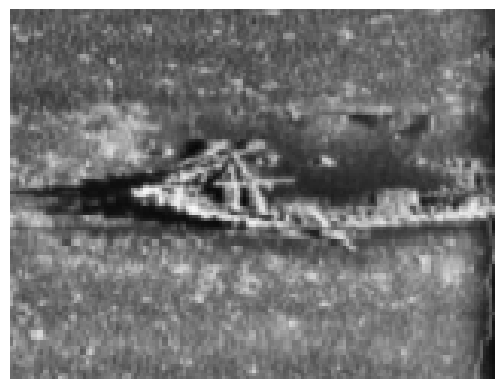

✅ Displaying: ship-001.png


In [18]:
# Example: Load and display an image from the test set using config
sample_image_path = os.path.join(config.test_images, 'ship', 'ship-001.png')

# Check if the specific image exists, if not find any ship image
if not os.path.exists(sample_image_path):
    ship_dir = os.path.join(config.test_images, 'ship')
    if os.path.exists(ship_dir):
        ship_images = [f for f in os.listdir(ship_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        if ship_images:
            sample_image_path = os.path.join(ship_dir, ship_images[0])
            print(f"📸 Using alternative image: {ship_images[0]}")
        else:
            print("⚠️  No ship images found!")
    else:
        print(f"⚠️  Ship directory not found: {ship_dir}")

display_image(sample_image_path)

In [19]:
# Perform inference with the best model using config paths
def safe_inference(image_path, classifier):
    """Perform inference with error handling"""
    try:
        if os.path.exists(image_path):
            image = Image.open(image_path).convert("RGB")
            predictions = classifier(image)
            return image, predictions, os.path.basename(image_path)
        else:
            print(f"❌ Image not found: {image_path}")
            return None, None, None
    except Exception as e:
        print(f"❌ Error during inference: {e}")
        return None, None, None

# Use the same image path we set up earlier
image, predictions, image_name = safe_inference(sample_image_path, classifier)

if image and predictions:
    # Get the best trial from the study
    best_trial = study.best_trial

    # Display predictions with enhanced formatting
    print("🔮 OPTIMIZED MODEL PREDICTION RESULTS")
    print("=" * 50)
    print(f"📸 Image: {image_name}")
    print(f"🏆 Best Model Accuracy: {best_trial.value:.4f}")
    print(f"🎯 Model Run ID: {run_id[:8]}...")
    print(f"💻 Device: {'GPU' if device >= 0 else 'CPU'}")
    print(f"📁 Test data path: {config.test_images}")

    print("\n📊 Prediction Confidence:")
    for i, pred in enumerate(predictions, 1):
        confidence = pred['score'] * 100
        bar_length = int(confidence / 2.5)  # Scale for visual bar
        bar = "█" * bar_length + "░" * (40 - bar_length)
        
        # Add emoji based on prediction
        emoji = "🛩️" if pred['label'] == 'plane' else "🚢" if pred['label'] == 'ship' else "🌊"
        
        print(f"   {i}. {emoji} {pred['label']:<10} {confidence:5.1f}% {bar}")

    print("=" * 50)

    # Show comparison with ground truth (assuming ship based on path)
    ground_truth = "ship" if "ship" in sample_image_path else "unknown"
    print(f"\n🎯 PREDICTION ANALYSIS:")
    print(f"   • Ground Truth: {ground_truth} 🚢")
    print(f"   • Top Prediction: {predictions[0]['label']} ({predictions[0]['score']*100:.1f}%)")
    print(f"   • Correct: {'✅ Yes' if predictions[0]['label'] == ground_truth else '❌ No'}")
    print("=" * 50)
else:
    print("❌ Could not perform inference - check data paths and model loading")

🔮 OPTIMIZED MODEL PREDICTION RESULTS
📸 Image: ship-001.png
🏆 Best Model Accuracy: 0.9446
🎯 Model Run ID: 6f1c959b...
💻 Device: GPU
📁 Test data path: /mnt/data/Seabed-Object-Classifier/test_set

📊 Prediction Confidence:
   1. 🚢 ship        90.0% ███████████████████████████████████░░░░░
   2. 🛩️ plane        7.7% ███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   3. 🌊 seafloor     2.3% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

🎯 PREDICTION ANALYSIS:
   • Ground Truth: ship 🚢
   • Top Prediction: ship (90.0%)
   • Correct: ✅ Yes


### Register Model Card in Domino's Registry

In [20]:
# Register model name in the model registry - use user-specific name
user_name = os.environ.get('DOMINO_USER_NAME', 'unknown')
model_name = f"Seabed-Classifier-{user_name}_ViT_Classification"
tags={'risk-level':'medium'} #list any desired model tags

 # Initiate MLFlow Client
client = mlflow.tracking.MlflowClient()

#Register model name in the model registry
try:
    client.create_registered_model(model_name, tags=tags)
except:
    print(f"model {model_name} already registered")

In [21]:
# Get the registered model, then update the model to version 1, add description etc.
# Update the model card using the model from the run above using config paths

# Model card template - use adaptive path for both project types
working_dir = os.environ.get('DOMINO_WORKING_DIR', '/mnt')
if working_dir == '/mnt/code':
    # Git-based project
    markdown_file = '/mnt/code/models/Model-Card-Template.md'
else:
    # File-based project
    markdown_file = os.path.join(working_dir, 'models', 'Model-Card-Template.md')

desc = 'Custom Model Registry - Optimized VIT Model'

# Check if markdown file exists
if os.path.exists(markdown_file):
    with open(markdown_file, 'r') as file:
        markdown_description = file.read()
        client.update_registered_model(model_name, markdown_description)
        print(f"✅ Updated model description from: {markdown_file}")
else:
    print(f"⚠️  Model card template not found: {markdown_file}")
    markdown_description = f"Optimized VIT model for seabed object classification trained with hyperparameter optimization"
    client.update_registered_model(model_name, markdown_description)

registered_model = client.get_registered_model(model_name)

# Extract comprehensive experiment data from best run
best_run_metrics = best_run.data.metrics
best_run_params = best_run.data.params

# Version tags (top 5 most relevant) - these go on the model VERSION
version_tags = {
    "accuracy": f"{best_run_metrics.get('accuracy', 0):.4f}",
    "ship_f1": f"{best_run_metrics.get('f1', 0):.4f}",  # Assuming 'f1' is ship F1 in optuna runs
    "auc_roc": f"{best_run_metrics.get('auc_roc', 0):.4f}",
    "training_time_min": f"{(best_run.info.end_time - best_run.info.start_time) / 60000:.2f}",  # Convert ms to minutes
    "dataset": "balanced" if 'balanced' in str(config.train_images) else "unbalanced"
}

# Calculate model size and parameters
try:
    model = mlflow.pytorch.load_model(model_uri)
    model_size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    model_size_mb = model_size_bytes / (1024 * 1024)
    total_params = sum(p.numel() for p in model.parameters())
except:
    # Fallback to estimated values
    model_size_mb = float(best_run_params.get('model_size', '346.0').replace(' MB', ''))
    total_params = int(best_run_params.get('total_params', '86000000').replace(',', ''))

# Model Specs tags (registered model level) - use mlflow.domino.specs.* prefix
model_specs = {
    "mlflow.domino.specs.Model Size": f"{model_size_mb:.1f} MB",
    "mlflow.domino.specs.Parameters": f"{total_params:,}",
    "mlflow.domino.specs.Architecture": "Vision Transformer (ViT-Base)",
    "mlflow.domino.specs.Input Resolution": f"{best_run_params.get('image_size', '224')}x{best_run_params.get('image_size', '224')}"
}

run_id = best_run.info.run_id

# Create a new model version from this run's `model` artifact
model_uri = f"runs:/{run_id}/model"
mv = client.create_model_version(
    name=model_name,
    source=model_uri,
    run_id=run_id, 
    description=desc, 
    tags=version_tags  # Changed from model_tags
)

for key, value in model_specs.items():
    client.set_registered_model_tag(model_name, key, value)
    
print(f"✅ Registered model version: {mv.version} for {model_name}")
print(f"✅ Version tags and Model Specs updated")
print(f"✅ Model URI: {model_uri}")
print(f"\nModel Summary:")
print(f"  📊 Accuracy: {version_tags['accuracy']}")
print(f"  🚢 Ship F1: {version_tags['ship_f1']}")
print(f"  📈 AUC-ROC: {version_tags['auc_roc']}")
print(f"  💾 Model Size: {model_specs['mlflow.domino.specs.Model Size']}")
print(f"  🔢 Parameters: {model_specs['mlflow.domino.specs.Parameters']}")
print(f"  ⏱️  Training time: {version_tags['training_time_min']} minutes")

✅ Updated model description from: /mnt/code/models/Model-Card-Template.md


2025/10/14 22:30:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Seabed-Classifier-andrea_lowe_ViT_Classification, version 1


✅ Registered model version: 1 for Seabed-Classifier-andrea_lowe_ViT_Classification
✅ Version tags and Model Specs updated
✅ Model URI: runs:/6f1c959b643c4502bc4add57a6be4515/model

Model Summary:
  📊 Accuracy: 0.9584
  🚢 Ship F1: 0.0000
  📈 AUC-ROC: 0.9945
  💾 Model Size: 346.0 MB
  🔢 Parameters: 86,000,000
  ⏱️  Training time: 1.42 minutes


## Clean-up

In [22]:
# Directory where your Trainer saved checkpoints using config
checkpoint_root = config.model_output_dir  # Use config for consistent paths

print(f"🧹 Cleaning up checkpoints in: {checkpoint_root}")

# Check if the directory exists
if not os.path.exists(checkpoint_root):
    print(f"⚠️  Checkpoint directory not found: {checkpoint_root}")
else:
    # 1) List all checkpoint folders (assuming they're named like "checkpoint-XXX")
    all_dirs = [
        d for d in os.listdir(checkpoint_root)
        if os.path.isdir(os.path.join(checkpoint_root, d)) and d.startswith("checkpoint-")
    ]

    if not all_dirs:
        print("ℹ️  No checkpoints found to clean up.")
    else:
        print(f"📊 Found {len(all_dirs)} checkpoint directories")
        
        # 2) Full paths, sorted by modification time
        paths = sorted(
            (os.path.join(checkpoint_root, d) for d in all_dirs),
            key=lambda p: os.path.getmtime(p)
        )
        latest_path = paths[-1]
        
        # 3) Target directory for your final model
        final_dir = os.path.join(checkpoint_root, "most-recent-checkpoint")
        
        # Remove any stale directory
        if os.path.exists(final_dir):
            shutil.rmtree(final_dir)
            print(f"🗑️  Removed old 'most-recent-checkpoint' directory")
        
        # 4) Rename the latest checkpoint
        shutil.move(latest_path, final_dir)
        print(f"✅ Kept latest checkpoint: {os.path.basename(latest_path)} → renamed to most-recent-checkpoint")
        
        # 5) Delete all the other checkpoint folders
        for old in paths[:-1]:
            shutil.rmtree(old)
            print(f"🗑️  Removed: {os.path.basename(old)}")
        
        print(f"✨ Cleanup complete! Saved {len(paths)-1} directories of space")
        print(f"📂 Final model location: {final_dir}")

🧹 Cleaning up checkpoints in: /mnt/artifacts/models/vit_classification_model
ℹ️  No checkpoints found to clean up.


In [23]:
# Enhanced Model Analysis and Validation
def comprehensive_model_analysis(study, best_model_path):
    """Perform comprehensive analysis of the best model"""
    
    print("🔬 COMPREHENSIVE MODEL ANALYSIS")
    print("=" * 70)
    
    # Best trial analysis
    best_trial = study.best_trial
    print(f"🏆 Best Ship F1-Score: {best_trial.value:.4f}")
    print(f"🔥 Best Trial Number: {best_trial.number}")
    print(f"📊 Total Trials: {len(study.trials)}")
    
    # Enhanced hyperparameter analysis
    print(f"\n🎛️  OPTIMAL HYPERPARAMETERS:")
    param_importance = {}
    for key, value in best_trial.params.items():
        if isinstance(value, float):
            print(f"   • {key}: {value:.6f}")
        else:
            print(f"   • {key}: {value}")
    
    # Parameter importance analysis (if available)
    try:
        importance = optuna.importance.get_param_importances(study)
        print(f"\n📈 PARAMETER IMPORTANCE:")
        for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
            print(f"   • {param}: {imp:.4f}")
    except:
        print(f"\n⚠️  Parameter importance analysis not available")
    
    # Trial performance distribution
    trial_values = [trial.value for trial in study.trials if trial.value is not None]
    if trial_values:
        print(f"\n📊 TRIAL PERFORMANCE STATISTICS:")
        print(f"   • Mean Ship F1: {np.mean(trial_values):.4f}")
        print(f"   • Std Ship F1: {np.std(trial_values):.4f}")
        print(f"   • Min Ship F1: {np.min(trial_values):.4f}")
        print(f"   • Max Ship F1: {np.max(trial_values):.4f}")
        print(f"   • Median Ship F1: {np.median(trial_values):.4f}")
    
    # Model configuration analysis
    if os.path.exists(best_model_path):
        print(f"\n🏗️  MODEL CONFIGURATION:")
        print(f"   • Model Path: {best_model_path}")
        print(f"   • Architecture: Vision Transformer (ViT)")
        print(f"   • Base Model: google/vit-base-patch16-224-in21k")
        print(f"   • Enhanced Dropout: 0.1 (hidden + attention)")
        print(f"   • Mixed Precision: FP16")
        print(f"   • Label Smoothing: Optimized")
        print(f"   • Gradient Clipping: Optimized")
    
    print("=" * 70)
    
    return {
        'best_trial': best_trial,
        'trial_statistics': {
            'mean': np.mean(trial_values) if trial_values else 0,
            'std': np.std(trial_values) if trial_values else 0,
            'min': np.min(trial_values) if trial_values else 0,
            'max': np.max(trial_values) if trial_values else 0,
            'median': np.median(trial_values) if trial_values else 0
        }
    }

# Enhanced final evaluation with comprehensive metrics
def final_model_evaluation(classifier, test_sample_count=20):
    """Perform final comprehensive evaluation on multiple test samples"""
    
    print("🧪 FINAL MODEL EVALUATION")
    print("=" * 70)
    
    # Test on multiple samples from each class
    test_results = {'plane': [], 'ship': [], 'seafloor': []}
    
    for class_name in config.classes:
        class_dir = os.path.join(config.test_images, class_name)
        if os.path.exists(class_dir):
            class_images = [f for f in os.listdir(class_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
            
            # Sample images for testing
            sample_images = class_images[:min(test_sample_count//3, len(class_images))]
            
            for img_name in sample_images:
                img_path = os.path.join(class_dir, img_name)
                try:
                    image = Image.open(img_path).convert("RGB")
                    predictions = classifier(image)
                    
                    # Store results
                    predicted_class = predictions[0]['label']
                    confidence = predictions[0]['score']
                    correct = predicted_class == class_name
                    
                    test_results[class_name].append({
                        'image': img_name,
                        'predicted': predicted_class,
                        'confidence': confidence,
                        'correct': correct
                    })
                except Exception as e:
                    print(f"   ⚠️  Error processing {img_name}: {e}")
    
    # Calculate final statistics
    print(f"\n📊 FINAL TEST RESULTS:")
    overall_correct = 0
    overall_total = 0
    
    for class_name, results in test_results.items():
        if results:
            correct_count = sum(1 for r in results if r['correct'])
            total_count = len(results)
            accuracy = correct_count / total_count if total_count > 0 else 0
            avg_confidence = np.mean([r['confidence'] for r in results])
            
            emoji = "🛩️" if class_name == 'plane' else "🚢" if class_name == 'ship' else "🌊"
            print(f"   {emoji} {class_name:<10}: {correct_count}/{total_count} ({accuracy:.3f}) - Avg Conf: {avg_confidence:.3f}")
            
            overall_correct += correct_count
            overall_total += total_count
    
    overall_accuracy = overall_correct / overall_total if overall_total > 0 else 0
    print(f"\n🎯 OVERALL TEST ACCURACY: {overall_correct}/{overall_total} ({overall_accuracy:.4f})")
    
    # Ship-specific analysis
    ship_results = test_results.get('ship', [])
    if ship_results:
        ship_correct = sum(1 for r in ship_results if r['correct'])
        ship_total = len(ship_results)
        ship_accuracy = ship_correct / ship_total if ship_total > 0 else 0
        ship_avg_conf = np.mean([r['confidence'] for r in ship_results])
        
        print(f"\n🚢 SHIP CLASS DETAILED ANALYSIS:")
        print(f"   • Ship Accuracy: {ship_correct}/{ship_total} ({ship_accuracy:.4f})")
        print(f"   • Average Confidence: {ship_avg_conf:.4f}")
        print(f"   • Misclassified Ships: {ship_total - ship_correct}")
    
    print("=" * 70)
    
    return {
        'overall_accuracy': overall_accuracy,
        'class_results': test_results,
        'ship_accuracy': ship_accuracy if ship_results else 0
    }

print("🎯 Enhanced Model Analysis Ready!")
print("   Use comprehensive_model_analysis(study, model_path) for detailed analysis")
print("   Use final_model_evaluation(classifier) for comprehensive testing")

🎯 Enhanced Model Analysis Ready!
   Use comprehensive_model_analysis(study, model_path) for detailed analysis
   Use final_model_evaluation(classifier) for comprehensive testing
